# Φάση Δ: Advanced Technique

Εμείς επιλέξαμε το K-Means


In [2]:
# =====================================================================
# GLOBAL CONFIGURATION FOR K-MEANS
# Αλλάξτε αυτή τη μεταβλητή εδώ και θα εφαρμοστεί αυτόματα σε όλο το notebook
# =====================================================================

SELECTED_K = 5

print(f"Ορίστηκε καθολικό K = {SELECTED_K}. Έτοιμο για χρήση στα επόμενα κελιά.")

Ορίστηκε καθολικό K = 5. Έτοιμο για χρήση στα επόμενα κελιά.


# Εκκίνηση SparkSession & Φόρτωση Δεδομένων

In [3]:
from pyspark.sql import SparkSession

# 1. Εκκίνηση του SparkSession
spark = SparkSession.builder \
    .appName("KMeans_Feature_Exploration") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("SparkSession αρχικοποιήθηκε με επιτυχία.")

# 2. Φόρτωση των DataFrames
df_silver = spark.read.parquet("../data/train_silver.parquet")
train_gold = spark.read.parquet("../data/train_gold.parquet")

print(f"Δεδομένα φορτώθηκαν. Gold Layer σχήμα: {train_gold.schema}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/12 04:11:26 WARN Utils: Your hostname, cachyos-x8664, resolves to a loopback address: 127.0.1.1; using 192.168.1.5 instead (on interface enp4s0)
26/06/12 04:11:26 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/12 04:11:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SparkSession αρχικοποιήθηκε με επιτυχία.
Δεδομένα φορτώθηκαν. Gold Layer σχήμα: StructType([StructField('features', VectorUDT(), True), StructField('stroke', LongType(), True)])


# Εμφάνιση χαρακτηριστικών του Gold Layer

In [4]:
import pyspark.sql.functions as F
from pyspark.ml.functions import vector_to_array
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType

# 1. Βρούμε τις κατηγορικές στήλες (_index) και εξάγουμε τα labels από τα Metadata
cat_cols = [field.name for field in df_silver.schema.fields if field.name.endswith("_index")]
human_categorical_names = []

for col in cat_cols:
    metadata = df_silver.schema[col].metadata
    if "ml_attr" in metadata and "vals" in metadata["ml_attr"]:
        distinct_vals = metadata["ml_attr"]["vals"]
    else:
        original_col_name = col.replace("_index", "")
        distinct_vals = [str(row[0]) for row in df_silver.select(original_col_name).distinct().sort(col).collect()]
    
    kept_vals = distinct_vals[:-1]
    original_col_name = col.replace("_index", "")
    for val in kept_vals:
        human_categorical_names.append(f"{original_col_name}_{val}")

# 2. Βρούμε τις αριθμητικές στήλες με τη σωστή σειρά
spark_numeric_types = (IntegerType, DoubleType, FloatType, LongType)
all_numeric_cols = [field.name for field in df_silver.schema.fields if isinstance(field.dataType, spark_numeric_types)]
numeric_cols = [c for c in all_numeric_cols if c != "stroke" and not c.endswith("_index")]

# --- ΠΡΟΣΘΗΚΗ: Υπολογισμός Standard Deviations από το df_silver για το Unscaling ---
# Υπολογίζουμε το stddev για κάθε αριθμητική στήλη απευθείας από το Silver layer
stddev_exprs = [F.stddev_samp(F.col(c)).alias(c) for c in numeric_cols]
stds_row = df_silver.select(stddev_exprs).collect()[0]
stds_dict = {c: stds_row[c] for c in numeric_cols}
# ---------------------------------------------------------------------------------

# 3. Ενώνουμε τις λίστες με την ακριβή σειρά που μπήκαν στον VectorAssembler
feature_names = human_categorical_names + numeric_cols
print(f"Συνολικά βρέθηκαν {len(feature_names)} διαστάσεις στο feature vector.")

# 4. Μετατροπή του Vector σε Array στο train_gold
df_look = train_gold.withColumn("features_array", vector_to_array("features"))

# 5. Χτίζουμε δυναμικά το select expression με ΑΠΟΚΑΝΟΝΙΚΟΠΟΙΗΣΗ (Unscaling)
select_exprs = [F.col("stroke")]

for i, name in enumerate(feature_names):
    # Αν η στήλη είναι αριθμητική, πολλαπλασιάζουμε με την τυπική απόκλιση (Unscaling)
    if name in numeric_cols:
        std_val = stds_dict[name]
        # features_array[i] * std_val
        select_exprs.append((F.col("features_array")[i] * F.lit(std_val)).alias(name))
    else:
        # Οι κατηγορικές (One-Hot) παραμένουν ως έχουν (0 ή 1)
        select_exprs.append(F.col("features_array")[i].alias(name))

# 6. Προβολή των 5 πρώτων γραμμών με τις πραγματικές (unscaled) τιμές
df_look.select(select_exprs).show(5, truncate=False)

Συνολικά βρέθηκαν 21 διαστάσεις στο feature vector.
+------+-------------+-----------+------------+----------------+---------------+-----------------+-----------------------+------------------+------------------+----------------------+--------------------+--------------------+---------------------------+----------------------+------------------------------+---------------------+-----------------+------------+-------------+------------------+------------------+
|stroke|gender_Female|gender_Male|gender_Other|ever_married_Yes|ever_married_No|work_type_Private|work_type_Self-employed|work_type_children|work_type_Govt_job|work_type_Never_worked|Residence_type_Urban|Residence_type_Rural|smoking_status_never smoked|smoking_status_Unknown|smoking_status_formerly smoked|smoking_status_smokes|age              |hypertension|heart_disease|avg_glucose_level |bmi               |
+------+-------------+-----------+------------+----------------+---------------+-----------------+-----------------------+

# Εφαρμογή βαρών στο gold για Feature Engineering

In [5]:
from pyspark.ml.linalg import Vectors, VectorUDT
import numpy as np
import pyspark.sql.functions as F

# 1. Δημιουργούμε έναν πίνακα με βάρη (αρχικά όλα 1.0) ίσο με το μέγεθος των features
num_features = len(feature_names)
weights_array = np.ones(num_features)

# --- FEATURE ENGINEERING: ΜΗΔΕΝΙΣΜΟΣ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΓΙΑ ΚΑΛΥΤΕΡΟ PERFORMANCE ---
# Φιλτράρουμε τις στήλες βάσει ονόματος και μηδενίζουμε όσες εισάγουν θόρυβο
for idx, name in enumerate(feature_names):
    if any(demographic in name for demographic in ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]):
        weights_array[idx] = 0.0

# Προαιρετικά: Μπορείς να δώσεις ακόμα μεγαλύτερη έμφαση στην ηλικία αν θες (π.χ. weights_array[feature_names.index("age")] = 2.0)
# ----------------------------------------------------------------------------------

print("=== ΝΕΟΣ ΠΙΝΑΚΑΣ ΒΑΡΩΝ ===")
for name, weight in zip(feature_names, weights_array):
    print(f"{name}: {weight}")

# 2. UDF για element-wise πολλαπλασιασμό του vector με τα βάρη
apply_weights_udf = F.udf(lambda vec: Vectors.dense(vec.toArray() * weights_array), VectorUDT())

# 3. Δημιουργία του modified_gold στην μνήμη χωρίς να αλλάξουμε το αρχικό αρχείο
modified_gold = train_gold.withColumn("features", apply_weights_udf("features"))

print("\nΤο modified_gold δημιουργήθηκε με επιτυχία και περιέχει μόνο το ιατρικό προφίλ των ασθενών!")

=== ΝΕΟΣ ΠΙΝΑΚΑΣ ΒΑΡΩΝ ===
gender_Female: 0.0
gender_Male: 0.0
gender_Other: 0.0
ever_married_Yes: 0.0
ever_married_No: 0.0
work_type_Private: 0.0
work_type_Self-employed: 0.0
work_type_children: 0.0
work_type_Govt_job: 0.0
work_type_Never_worked: 0.0
Residence_type_Urban: 0.0
Residence_type_Rural: 0.0
smoking_status_never smoked: 0.0
smoking_status_Unknown: 0.0
smoking_status_formerly smoked: 0.0
smoking_status_smokes: 0.0
age: 1.0
hypertension: 1.0
heart_disease: 1.0
avg_glucose_level: 1.0
bmi: 1.0

Το modified_gold δημιουργήθηκε με επιτυχία και περιέχει μόνο το ιατρικό προφίλ των ασθενών!


# Elbow Method & Silhouette Score πάνω στο modified_gold

Μας βοηθάει να επιλέξουμε το σωστό k για το k-Means

Έναρξη αξιολόγησης του modified_gold...
Εκπαίδευση μοντέλου για K = 2...


 -> K = 2: WSSSE = 30879.71 | Silhouette Score = 0.6366
Εκπαίδευση μοντέλου για K = 3...


 -> K = 3: WSSSE = 24098.72 | Silhouette Score = 0.3605
Εκπαίδευση μοντέλου για K = 4...


 -> K = 4: WSSSE = 22633.74 | Silhouette Score = 0.5431
Εκπαίδευση μοντέλου για K = 5...


 -> K = 5: WSSSE = 12183.38 | Silhouette Score = 0.5746
Εκπαίδευση μοντέλου για K = 6...


 -> K = 6: WSSSE = 9690.17 | Silhouette Score = 0.5955
Εκπαίδευση μοντέλου για K = 7...


 -> K = 7: WSSSE = 8670.86 | Silhouette Score = 0.5368
Εκπαίδευση μοντέλου για K = 8...


 -> K = 8: WSSSE = 8104.80 | Silhouette Score = 0.5033


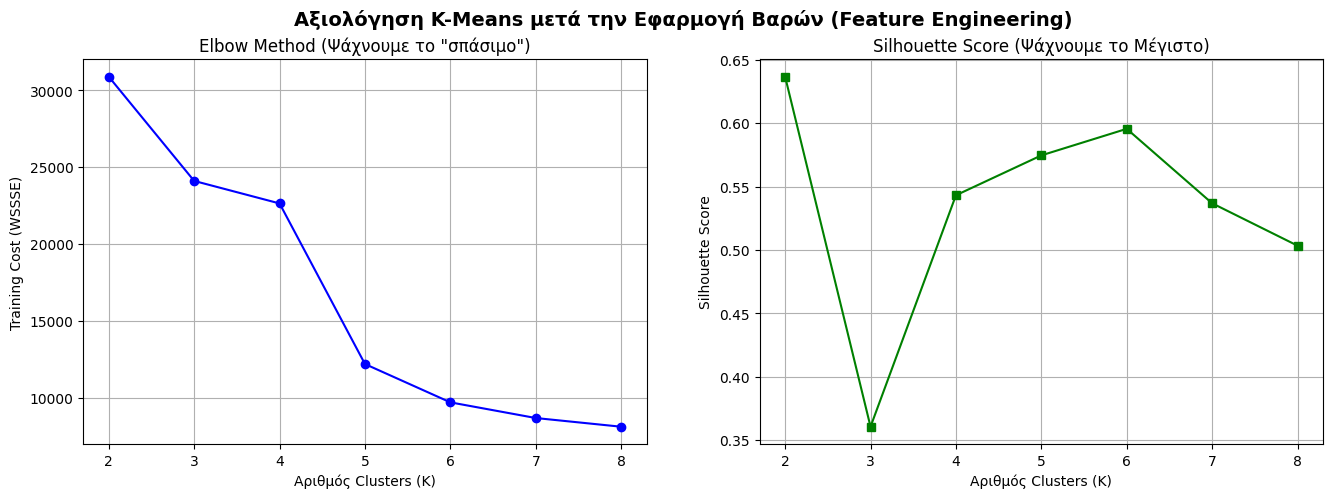

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("Έναρξη αξιολόγησης του modified_gold...")

# 1. Αρχικοποίηση λιστών για την αποθήκευση των μετρικών
costs = []
silhouette_scores = []
k_range = range(2, 9)  # Δοκιμάζουμε Κ από 2 έως 8 όπως στην αρχική μελέτη

# 2. Ορισμός του Evaluator για το Silhouette Score
evaluator = ClusteringEvaluator(
    predictionCol="cluster", 
    featuresCol="features", 
    metricName="silhouette"
)

# 3. Εκτέλεση του Loop για κάθε K
for k_val in k_range:
    print(f"Εκπαίδευση μοντέλου για K = {k_val}...")
    
    # Ορισμός και εκπαίδευση του KMeans με σταθερό seed για αναπαραγωγιμότητα
    km = KMeans(featuresCol="features", predictionCol="cluster", k=k_val, seed=42)
    model = km.fit(modified_gold)
    
    # α) Υπολογισμός Training Cost (WSSSE) για την Elbow Method
    cost = model.summary.trainingCost
    costs.append(cost)
    
    # β) Παραγωγή προβλέψεων και υπολογισμός Silhouette Score
    predictions = model.transform(modified_gold)
    score = evaluator.evaluate(predictions)
    silhouette_scores.append(score)
    
    print(f" -> K = {k_val}: WSSSE = {cost:.2f} | Silhouette Score = {score:.4f}")

# 4. Σχεδίαση Γραφημάτων (Δίπλα-Δίπλα για εύκολη σύγκριση)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Γράφημα 1: Elbow Method
ax1.plot(list(k_range), costs, marker='o', linestyle='-', color='b')
ax1.set_xlabel('Αριθμός Clusters (K)')
ax1.set_ylabel('Training Cost (WSSSE)')
ax1.set_title('Elbow Method (Ψάχνουμε το "σπάσιμο")')
ax1.grid(True)

# Γράφημα 2: Silhouette Score
ax2.plot(list(k_range), silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_xlabel('Αριθμός Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (Ψάχνουμε το Μέγιστο)')
ax2.grid(True)

plt.suptitle('Αξιολόγηση K-Means μετά την Εφαρμογή Βαρών (Feature Engineering)', fontsize=14, fontweight='bold')
plt.show()

# Ορθή Εφαρμογή PCA σε Train και Test Sets


In [7]:
from pyspark.ml.feature import PCA
import pyspark.sql.functions as F

print("Έναρξη διαδικασίας μείωσης διαστασιμότητας με PCA (k=2)...")

# 1. Φόρτωση και του test_gold (αν δεν είναι ήδη φορτωμένο)
test_gold = spark.read.parquet("../data/test_gold.parquet")

# 2. Ορισμός του PCA μοντέλου
# Επιλέγουμε k=2 κυρίως συστατώσες για να μπορούμε να κάνουμε 2D οπτικοποίηση
pca = PCA(k=2, inputCol="features", outputCol="pca_features")

# 3. ΕΚΠΑΙΔΕΥΣΗ (Fit) ΜΟΝΟ ΣΤΟ TRAIN GOLD
# Υπολογισμός των ιδιοδιανυσμάτων αποκλειστικά από τα δεδομένα εκπαίδευσης
pca_model = pca.fit(train_gold)

# 4. ΜΕΤΑΣΧΗΜΑΤΙΣΜΟΣ (Transform) ΚΑΙ ΣΤΑ ΔΥΟ DATASETS
# Εφαρμόζουμε την ίδια ακριβώς προβολή και στα δύο σύνολα
train_pca = pca_model.transform(train_gold)
test_pca = pca_model.transform(test_gold)

# 5. Επιβεβαίωση αποτελεσμάτων και εμφάνιση δείγματος
print("\n=== TRAIN DATASET ΜΕ PCA FEATURES ===")
train_pca.select("stroke", "features", "pca_features").show(3, truncate=True)

print("=== TEST DATASET ΜΕ PCA FEATURES ===")
test_pca.select("stroke", "features", "pca_features").show(3, truncate=True)

# Επεξήγηση της διακύμανσης (Explained Variance)
explained_variance = pca_model.explainedVariance
print(f"\nΠοσοστό πληροφορίας που διατηρήθηκε:")
print(f" -> PC1: {explained_variance[0]*100:.2f}%")
print(f" -> PC2: {explained_variance[1]*100:.2f}%")
print(f" -> Συνολική πληροφορία (PC1 + PC2): {sum(explained_variance)*100:.2f}%")

Έναρξη διαδικασίας μείωσης διαστασιμότητας με PCA (k=2)...



=== TRAIN DATASET ΜΕ PCA FEATURES ===
+------+--------------------+--------------------+
|stroke|            features|        pca_features|
+------+--------------------+--------------------+
|     1|(21,[1,3,6,11,15,...|[4.09100954747156...|
|     1|(21,[0,3,5,11,13,...|[4.44356799591138...|
|     1|(21,[1,3,5,11,12,...|[5.65476234798833...|
+------+--------------------+--------------------+
only showing top 3 rows
=== TEST DATASET ΜΕ PCA FEATURES ===
+------+--------------------+--------------------+
|stroke|            features|        pca_features|
+------+--------------------+--------------------+
|     0|(21,[0,4,7,11,13,...|[1.21718069522327...|
|     0|(21,[0,4,7,11,13,...|[1.70074912836987...|
|     0|(21,[0,4,7,10,13,...|[1.26885363540631...|
+------+--------------------+--------------------+
only showing top 3 rows

Ποσοστό πληροφορίας που διατηρήθηκε:
 -> PC1: 23.83%
 -> PC2: 13.65%
 -> Συνολική πληροφορία (PC1 + PC2): 37.48%


Εκπαίδευση K-Means (K=5) πάνω στα PCA χαρακτηριστικά...


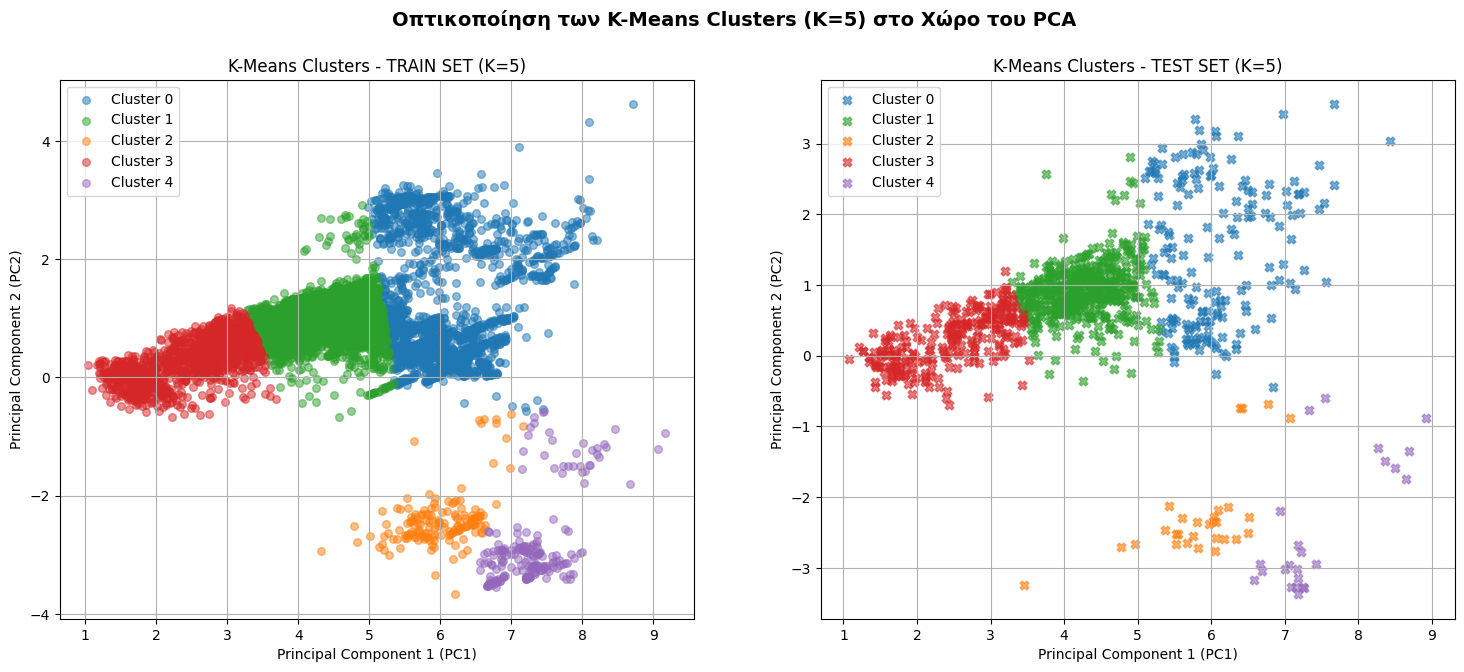

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml.clustering import KMeans

print(f"Εκπαίδευση K-Means (K={SELECTED_K}) πάνω στα PCA χαρακτηριστικά...")

# 1. Ορισμός και εκπαίδευση του μοντέλου KMeans στα PCA χαρακτηριστικά του Train set
kmeans_pca = KMeans(featuresCol="pca_features", predictionCol="cluster", k=SELECTED_K, seed=22390225)
model_pca = kmeans_pca.fit(train_pca)

# 2. Παραγωγή προβλέψεων (Cluster Assignments) για Train και Test
train_preds = model_pca.transform(train_pca)
test_preds = model_pca.transform(test_pca)

# 3. Μετατροπή σε Pandas ΜΟΝΟ για τη σχεδίαση των γραφημάτων
plot_train_df = train_preds.select("pca_features", "cluster").toPandas()
plot_test_df = test_preds.select("pca_features", "cluster").toPandas()

# Συνάρτηση για την εξαγωγή των PC1 και PC2 από το Vector σε ξεχωριστές στήλες Pandas
def extract_pcs(df):
    df['PC1'] = df['pca_features'].apply(lambda vec: float(vec[0]))
    df['PC2'] = df['pca_features'].apply(lambda vec: float(vec[1]))
    return df

plot_train_df = extract_pcs(plot_train_df)
plot_test_df = extract_pcs(plot_test_df)

# 4. Δημιουργία των Γραφημάτων (Δίπλα-Δίπλα)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ΕΝΗΜΕΡΩΜΕΝΟ: Λεξικό με 5 χρώματα για τα Clusters 0, 1, 2, 3, 4
colors = {
    0: '#1f77b4',  # Μπλε
    1: '#2ca02c',  # Πράσινο
    2: '#ff7f0e',  # Πορτοκαλί
    3: '#d62728',  # Κόκκινο
    4: '#9467bd'   # Μοβ
}

# Γράφημα Α: Train Set Clusters
for cluster_id in sorted(plot_train_df['cluster'].unique()):
    cluster_data = plot_train_df[plot_train_df['cluster'] == cluster_id]
    # Μετατροπή του cluster_id σε απλό int για ασφάλεια με το mapping του dict
    cid_int = int(cluster_id)
    ax1.scatter(
        cluster_data['PC1'], cluster_data['PC2'],
        color=colors.get(cid_int, '#7f7f7f'), alpha=0.5, s=30,
        label=f'Cluster {cid_int}'
    )
ax1.set_xlabel('Principal Component 1 (PC1)')
ax1.set_ylabel('Principal Component 2 (PC2)')
ax1.set_title(f'K-Means Clusters - TRAIN SET (K={SELECTED_K})')
ax1.legend()
ax1.grid(True)

# Γράφημα Β: Test Set Clusters (Γενίκευση Μοντέλου)
for cluster_id in sorted(plot_test_df['cluster'].unique()):
    cluster_data = plot_test_df[plot_test_df['cluster'] == cluster_id]
    cid_int = int(cluster_id)
    ax2.scatter(
        cluster_data['PC1'], cluster_data['PC2'],
        color=colors.get(cid_int, '#7f7f7f'), alpha=0.6, s=40, marker='X',
        label=f'Cluster {cid_int}'
    )
ax2.set_xlabel('Principal Component 1 (PC1)')
ax2.set_ylabel('Principal Component 2 (PC2)')
ax2.set_title(f'K-Means Clusters - TEST SET (K={SELECTED_K})')
ax2.legend()
ax2.grid(True)

plt.suptitle(f'Οπτικοποίηση των K-Means Clusters (K={SELECTED_K}) στο Χώρο του PCA', fontsize=14, fontweight='bold')
plt.show()

# Εκπαίδευση στο Train και Πρόβλεψη στο Test Dataset

In [9]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print(f"Έναρξη εκπαίδευσης του K-Means (K={SELECTED_K}) στο Training Dataset...")

# 1. Ορισμός του μοντέλου K-Means με βάση τις παραμέτρους της ομάδας σας
# Χρησιμοποιούμε k={SELECTED_K} και το συγκεκριμένο seed για σταθερά αποτελέσματα
kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=SELECTED_K, seed=22390225)

# 2. ΕΚΠΑΙΔΕΥΣΗ (Fit) αποκλειστικά στο Training Dataset
kmeans_model = kmeans.fit(train_gold)
print("Η εκπαίδευση του μοντέλου ολοκληρώθηκε.")

# 3. ΕΦΑΡΜΟΓΗ (Transform) στο Test Dataset για την παραγωγή προβλέψεων
test_preds = kmeans_model.transform(test_gold)
print("Οι προβλέψεις στο Test Dataset δημιουργήθηκαν.")

# 4. ΑΞΙΟΛΟΓΗΣΗ: Υπολογισμός του Silhouette Score στο Test Dataset
evaluator = ClusteringEvaluator(predictionCol="cluster", featuresCol="features", metricName="silhouette")
test_silhouette = evaluator.evaluate(test_preds)

print("\n=================== ΑΠΟΤΕΛΕΣΜΑΤΑ TEST SET ===================")
print(f"Silhouette Score στα άγνωστα δεδομένα (Test Set): {test_silhouette:.4f}")

# 5. Εμφάνιση δείγματος των αποτελεσμάτων (Cluster Assignments) μαζί με το πραγματικό stroke
print("\nΔείγμα προβλέψεων από το Test Set:")
test_preds.select("stroke", "cluster").show(10, truncate=False)

Έναρξη εκπαίδευσης του K-Means (K=5) στο Training Dataset...
Η εκπαίδευση του μοντέλου ολοκληρώθηκε.
Οι προβλέψεις στο Test Dataset δημιουργήθηκαν.

=================== ΑΠΟΤΕΛΕΣΜΑΤΑ TEST SET ===================
Silhouette Score στα άγνωστα δεδομένα (Test Set): 0.2999

Δείγμα προβλέψεων από το Test Set:
+------+-------+
|stroke|cluster|
+------+-------+
|0     |4      |
|0     |4      |
|0     |4      |
|0     |4      |
|0     |4      |
|0     |4      |
|0     |4      |
|0     |4      |
|0     |4      |
|0     |4      |
+------+-------+
only showing top 10 rows


# Δημιουργία πρόβλεψης και στο train gold και αποθήκευση train & test gold μοντέλου kmeans

In [10]:
# =====================================================================
# ΣΤΑΔΙΟ: ΑΠΟΘΗΚΕΥΣΗ ΠΡΟΒΛΕΨΕΩΝ CLUSTERS ΓΙΑ CLASSIFICATION
# =====================================================================
print("\nΈναρξη παραγωγής και αποθήκευσης των Cluster Predictions...")

# 1. Παράγουμε τις προβλέψεις (cluster assignments) και για το Train Set
train_preds = kmeans_model.transform(train_gold)
print("Οι προβλέψεις για το Training Dataset δημιουργήθηκαν.")

# 2. Αποθήκευση των DataFrames σε Parquet
# Κρατάμε όλες τις αρχικές στήλες (features, stroke) και προσθέτουμε τη στήλη cluster
train_preds.write.mode("overwrite").parquet("../data/train_gold_with_cluster.parquet")
test_preds.write.mode("overwrite").parquet("../data/test_gold_with_cluster.parquet")

print(" -> Το train_gold_with_cluster.parquet αποθηκεύτηκε επιτυχώς!")
print(" -> Το test_gold_with_cluster.parquet αποθηκεύτηκε επιτυχώς!")
print("\nΌλα έτοιμα! Τα Parquet αρχεία περιλαμβάνουν τη στήλη 'cluster' και είναι έτοιμα για τα classification μοντέλα.")


Έναρξη παραγωγής και αποθήκευσης των Cluster Predictions...
Οι προβλέψεις για το Training Dataset δημιουργήθηκαν.
 -> Το train_gold_with_cluster.parquet αποθηκεύτηκε επιτυχώς!
 -> Το test_gold_with_cluster.parquet αποθηκεύτηκε επιτυχώς!

Όλα έτοιμα! Τα Parquet αρχεία περιλαμβάνουν τη στήλη 'cluster' και είναι έτοιμα για τα classification μοντέλα.


# Ποσοστό Stroke Ανα Cluster

In [11]:

# 4. Μετατροπή σε Pandas και υπολογισμός
import pandas as pd
pdf_true_test = test_preds.select("cluster", "stroke").toPandas()

print("==================================================")
print("ΠΡΑΓΜΑΤΙΚΟ TEST: ΠΟΣΟΣΤΟ (%) STROKE ANA CLUSTER")
print("==================================================")
stroke_profile_test = pdf_true_test.groupby("cluster").mean() * 100
print(stroke_profile_test.round(1).to_string())

ΠΡΑΓΜΑΤΙΚΟ TEST: ΠΟΣΟΣΤΟ (%) STROKE ANA CLUSTER
         stroke
cluster        
0          11.9
1           5.1
2           1.8
3          13.0
4           0.0


In [12]:
import pandas as pd
import numpy as np
import pyspark.sql.functions as F

# 1. Φόρτωση των DataFrames
df_silver = spark.read.parquet("../data/train_silver.parquet")

# 2. Native PySpark Extraction των Categorical Labels από τα Metadata
human_categorical_names = []
cat_cols = [field.name for field in df_silver.schema.fields if field.name.endswith("_index")]

for col in cat_cols:
    # Παίρνουμε τα metadata της στήλης
    metadata = df_silver.schema[col].metadata
    
    # Αν η στήλη έχει περάσει από StringIndexer, τα labels υπάρχουν έτοιμα εδώ:
    if "ml_attr" in metadata and "vals" in metadata["ml_attr"]:
        distinct_vals = metadata["ml_attr"]["vals"]
    else:
        # Fallback αν δεν υπάρχουν metadata (διαβάζουμε τις τιμές native)
        original_col_name = col.replace("_index", "")
        distinct_vals = [str(row[0]) for row in df_silver.select(original_col_name).distinct().sort(col).collect()]
    
    # Το OneHotEncoder (dropLast=True) πετάει πάντα την τελευταία τιμή
    kept_vals = distinct_vals[:-1]
    
    # Φτιάχνουμε τα τελικά ονόματα
    original_col_name = col.replace("_index", "")
    for val in kept_vals:
        human_categorical_names.append(f"{original_col_name}_{val}")

num_cat_features = len(human_categorical_names)

# 3. Μετατροπή των predictions σε Pandas (Μόνο για το τελικό group/report)
pdf_gold = test_preds.select("features", "cluster").toPandas()
features_matrix = np.vstack(pdf_gold['features'].apply(lambda x: x.toArray()))

# 4. Απομόνωση του categorical κομματιού και δημιουργία του DataFrame
cat_features_matrix = features_matrix[:, 0:num_cat_features]
cat_features_binary = (cat_features_matrix > 0.001).astype(int)

pdf_cat_human = pd.DataFrame(cat_features_binary, columns=human_categorical_names)
pdf_cat_human['cluster'] = pdf_gold['cluster']

# 5. Τελικό Report Ποσοστών
print("\n" + "="*80)
print("=== ΑΝΘΡΩΠΙΝΑ ΠΟΣΟΣΤΑ (%) ΚΑΤΗΓΟΡΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===")
print("="*80)
cat_profile_human = pdf_cat_human.groupby('cluster').mean() * 100
print(cat_profile_human.round(1).T.to_string())


=== ΑΝΘΡΩΠΙΝΑ ΠΟΣΟΣΤΑ (%) ΚΑΤΗΓΟΡΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===
cluster                            0     1     2     3     4
gender_Female                   48.3  63.1  60.7  31.5  49.2
gender_Male                     51.7  36.9  39.3  68.5  50.8
gender_Other                     0.0   0.0   0.0   0.0   0.0
ever_married_Yes                92.4  94.9  84.8  88.9   5.0
ever_married_No                  7.6   5.1  15.2  11.1  95.0
work_type_Private               51.7  58.3  71.4  55.6  44.2
work_type_Self-employed         27.1  24.8  12.5  27.8   3.8
work_type_children               0.0   0.0   0.4   1.9  45.8
work_type_Govt_job              21.2  16.9  15.6  14.8   4.6
work_type_Never_worked           0.0   0.0   0.0   0.0   1.5
Residence_type_Urban            48.3  54.7  54.5  44.4  51.5
Residence_type_Rural            51.7  45.3  45.5  55.6  48.5
smoking_status_never smoked     45.8  41.7  40.6  31.5  23.8
smoking_status_Unknown          18.6  22.1  23.2  18.5  60.0
smoking_status

In [13]:
import pandas as pd
import numpy as np
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType

# 1. Φόρτωση του Silver DataFrame (για τον υπολογισμό των STDs)
df_silver = spark.read.parquet("../data/train_silver.parquet")

# ==========================================
# ΑΥΤΟΜΑΤΟΣ ΔΙΑΧΩΡΙΣΜΟΣ ΜΕ NATIVE PYSPARK (FIXED)
# ==========================================
spark_numeric_types = (IntegerType, DoubleType, FloatType, LongType)
all_numeric_cols = [field.name for field in df_silver.schema.fields if isinstance(field.dataType, spark_numeric_types)]

numeric_cols = [c for c in all_numeric_cols if c != "stroke" and not c.endswith("_index")]
cat_cols = [c for c in all_numeric_cols if c.endswith("_index")]

# 2. Native PySpark Υπολογισμός των STDs (απαραίτητο για το ξε-κανονικοποίηση)
std_exprs = [F.stddev_samp(F.col(c)).alias(c) for c in numeric_cols]
stds_dict = df_silver.select(*std_exprs).first().asDict()

# 3. Εξαγωγή των scaled αριθμητικών χαρακτηριστικών από το Test Προβλέψεων
pdf_gold = test_preds.select("features", "cluster").toPandas()
features_matrix = np.vstack(pdf_gold['features'].apply(lambda x: x.toArray()))

# Βρίσκουμε δυναμικά πού ξεκινούν οι αριθμητικές στήλες στο vector
num_cat_features = features_matrix.shape[1] - len(numeric_cols)
numeric_features_scaled = features_matrix[:, num_cat_features:]

# 4. Δημιουργία DataFrame με τις ΠΡΑΓΜΑΤΙΚΕΣ (Unscaled) τιμές
pdf_numeric_unscaled = pd.DataFrame(columns=numeric_cols)
for i, col in enumerate(numeric_cols):
    pdf_numeric_unscaled[col] = numeric_features_scaled[:, i] * stds_dict[col]

# Προσθήκη της στήλης του cluster
pdf_numeric_unscaled['cluster'] = pdf_gold['cluster']

# 5. Τελικό Report ανά Cluster
print("\n" + "="*90)
print("=== ΣΤΑΤΙΣΤΙΚΟ ΠΡΟΦΙΛ ΠΡΑΓΜΑΤΙΚΩΝ ΑΡΙΘΜΗΤΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===")
print("="*90)

cluster_profiles = pdf_numeric_unscaled.groupby('cluster')[numeric_cols].agg(['mean', 'min', 'max', 'std'])

for cluster_id in sorted(pdf_numeric_unscaled['cluster'].unique()):
    print(f"\n--- CLUSTER {cluster_id} ---")
    print(cluster_profiles.loc[cluster_id].unstack(level=1).round(2).to_string())


=== ΣΤΑΤΙΣΤΙΚΟ ΠΡΟΦΙΛ ΠΡΑΓΜΑΤΙΚΩΝ ΑΡΙΘΜΗΤΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===

--- CLUSTER 0 ---
                     mean     min     max    std
age                 62.96   26.35   83.12  13.17
hypertension         0.27    0.00    1.01   0.45
heart_disease        0.00    0.00    0.00   0.00
avg_glucose_level  171.13  109.66  216.87  21.15
bmi                 38.47   24.96   66.06   7.90

--- CLUSTER 1 ---
                    mean    min     max    std
age                58.58  28.38   83.12  14.23
hypertension        0.10   0.00    1.01   0.30
heart_disease       0.00   0.00    0.00   0.00
avg_glucose_level  73.28  45.52  136.11  16.44
bmi                31.79  13.31   43.22   4.08

--- CLUSTER 2 ---
                    mean    min     max    std
age                43.83  13.18   82.10  12.67
hypertension        0.07   0.00    1.01   0.25
heart_disease       0.00   0.00    0.00   0.00
avg_glucose_level  76.12  45.62  182.31  23.75
bmi                44.67  32.15   76.31   8.22

--- C

# Έναρξη Στοχευμένης Διόρθωσης Πολυσυγγραμικότητας (dropLast και drop θορυβου)

In [14]:
from pyspark.ml.feature import VectorSlicer

print("=== ΕΝΑΡΞΗ ΣΤΟΧΕΥΜΕΝΗΣ ΔΙΟΡΘΩΣΗΣ ΠΟΛΥΣΥΓΓΡΑΜΙΚΟΤΗΤΑΣ (OPTIMIZED) ===")

# 1. Φόρτωση (Όπως το είχες)
train_gold_clustered = spark.read.parquet("../data/train_gold_with_cluster.parquet")
test_gold_clustered = spark.read.parquet("../data/test_gold_with_cluster.parquet")

# 2. Οι στήλες που θέλεις να ΠΕΤΑΞΕΙΣ (drop)
cols_to_drop = [
    "gender_Male", "gender_Other", "ever_married_No", 
    "Residence_type_Rural", "work_type_Never_worked", 
    "work_type_Govt_job", "smoking_status_Unknown"
]

# 3. Βρες τα index των στηλών που ΘΕΛΟΥΜΕ ΝΑ ΚΡΑΤΗΣΟΥΜΕ (keep)
indices_to_keep = [
    idx for idx, name in enumerate(feature_names) if name not in cols_to_drop
]

print(f"Αρχικά features: {len(feature_names)} -> Τελικά features: {len(indices_to_keep)}")

# 4. Χρήση του Native VectorSlicer αντί για Python UDF
slicer = VectorSlicer(
    inputCol="features", 
    outputCol="features_filtered", 
    indices=indices_to_keep
)

# Εφαρμογή του μετασχηματισμού
train_gold_corrected = slicer.transform(train_gold_clustered).drop("features").withColumnRenamed("features_filtered", "features")
test_gold_corrected = slicer.transform(test_gold_clustered).drop("features").withColumnRenamed("features_filtered", "features")

# 5. Αποθήκευση (Όπως το είχες)
train_gold_corrected.write.mode("overwrite").parquet("../data/train_gold_corrected.parquet")
test_gold_corrected.write.mode("overwrite").parquet("../data/test_gold_corrected.parquet")

print("\nΤα αρχεία αποθηκεύτηκαν επιτυχώς και είναι optimized για SVM/Logistic Regression!")

=== ΕΝΑΡΞΗ ΣΤΟΧΕΥΜΕΝΗΣ ΔΙΟΡΘΩΣΗΣ ΠΟΛΥΣΥΓΓΡΑΜΙΚΟΤΗΤΑΣ (OPTIMIZED) ===
Αρχικά features: 21 -> Τελικά features: 14

Τα αρχεία αποθηκεύτηκαν επιτυχώς και είναι optimized για SVM/Logistic Regression!


# Προβολή διορθωμένου Gold Layer (με dropLast και drop θορυβου)

In [15]:
import pyspark.sql.functions as F
from pyspark.ml.functions import vector_to_array

print("=== ΕΛΕΓΧΟΣ ΔΙΟΡΘΩΜΕΝΟΥ DATASET ===")

# 1. Φόρτωση του νέου διορθωμένου αρχείου
df_check = spark.read.parquet("../data/train_gold_corrected.parquet")

# 2. Οι στήλες που αφαιρέθηκαν (για να τις βγάλουμε και από το print)
cols_to_drop = [
    "gender_Male", "gender_Other", "ever_married_No", 
    "Residence_type_Rural", "work_type_Never_worked", 
    "work_type_Govt_job", "smoking_status_Unknown"
]

# 3. Κρατάμε ΜΟΝΟ τα ονόματα των στηλών που υπάρχουν πλέον στο Vector
active_feature_names = [name for name in feature_names if name not in cols_to_drop]

# 4. Μετατροπή Vector σε Array
df_look = df_check.withColumn("features_array", vector_to_array("features"))

# 5. Χτίζουμε δυναμικά το select expression με τη ΣΩΣΤΗ λίστα στηλών
select_exprs = [F.col("stroke"), F.col("cluster")] 
for i, name in enumerate(active_feature_names):
    select_exprs.append(F.col("features_array")[i].alias(name))

# 6. Προβολή των πρώτων 5 γραμμών
print(f"Συνολικό σχήμα: {df_check.count()} γραμμές")
print(f"Αρχική Διάσταση Vector: {len(feature_names)} -> Νέα Διάσταση: {len(active_feature_names)}")
print("Οι στήλες που αφαιρέθηκαν δεν υπάρχουν καν στο vector πλέον (κέρδος σε μνήμη/ταχύτητα):\n")

df_look.select(select_exprs).show(5, truncate=False)

=== ΕΛΕΓΧΟΣ ΔΙΟΡΘΩΜΕΝΟΥ DATASET ===
Συνολικό σχήμα: 7832 γραμμές
Αρχική Διάσταση Vector: 21 -> Νέα Διάσταση: 14
Οι στήλες που αφαιρέθηκαν δεν υπάρχουν καν στο vector πλέον (κέρδος σε μνήμη/ταχύτητα):

+------+-------+-------------+----------------+-----------------+-----------------------+------------------+--------------------+---------------------------+------------------------------+---------------------+------------------+------------+-------------+------------------+-----------------+
|stroke|cluster|gender_Female|ever_married_Yes|work_type_Private|work_type_Self-employed|work_type_children|Residence_type_Urban|smoking_status_never smoked|smoking_status_formerly smoked|smoking_status_smokes|age               |hypertension|heart_disease|avg_glucose_level |bmi              |
+------+-------+-------------+----------------+-----------------+-----------------------+------------------+--------------------+---------------------------+------------------------------+---------------------+-

# Βεβαίωση ότι υπάρχει μέσα στο corrected dataset και το cluster 

In [16]:
print("=== ΕΛΕΓΧΟΣ ΥΠΑΡΞΗΣ ΣΤΗΛΗΣ 'CLUSTER' ===")

# 1. Φόρτωση του διορθωμένου DataFrame
train_gold_corrected = spark.read.parquet("../data/train_gold_corrected.parquet")

# 2. Ανάκτηση λίστας με τα ονόματα όλων των στηλών
columns = train_gold_corrected.columns
print(f"Συνολικές στήλες στο αρχείο: {columns}")

# 3. Έλεγχος για το αν υπάρχει το 'cluster'
if "cluster" in columns:
    print("\n[ΕΠΙΤΥΧΙΑ] Η στήλη 'cluster' ΥΠΑΡΧΕΙ κανονικά στο διορθωμένο dataset!")
    print("Δείγμα δεδομένων:")
    # Προβολή των πρώτων 5 γραμμών (stroke και cluster)
    train_gold_corrected.select("stroke", "cluster").show(5)
else:
    print("\n[ΠΡΟΒΛΗΜΑ] Η στήλη 'cluster' ΔΕΝ βρέθηκε στο dataset.")

=== ΕΛΕΓΧΟΣ ΥΠΑΡΞΗΣ ΣΤΗΛΗΣ 'CLUSTER' ===
Συνολικές στήλες στο αρχείο: ['stroke', 'cluster', 'features']

[ΕΠΙΤΥΧΙΑ] Η στήλη 'cluster' ΥΠΑΡΧΕΙ κανονικά στο διορθωμένο dataset!
Δείγμα δεδομένων:
+------+-------+
|stroke|cluster|
+------+-------+
|     1|      1|
|     1|      1|
|     1|      0|
|     1|      1|
|     1|      1|
+------+-------+
only showing top 5 rows
